In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("Asm1_dataset26.csv")

In [3]:
df.head()
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2789 entries, 0 to 2788
Data columns (total 45 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Hectares                            2789 non-null   int64  
 1   Agriblock                           2789 non-null   object 
 2   Variety                             2789 non-null   object 
 3   Soil Types                          2789 non-null   object 
 4   Seedrate(in Kg)                     2789 non-null   int64  
 5   LP_Mainfield(in Tonnes)             2789 non-null   float64
 6   Nursery                             2789 non-null   object 
 7   Nursery area (Cents)                2789 non-null   int64  
 8   LP_nurseryarea(in Tonnes)           2789 non-null   int64  
 9   DAP_20days                          2789 non-null   int64  
 10  Weed28D_thiobencarb                 2789 non-null   int64  
 11  Urea_40Days                         2789 no

,0
Hectares,0
Agriblock,0
Variety,0
Soil Types,0
Seedrate(in Kg),0
LP_Mainfield(in Tonnes),0
Nursery,0
Nursery area (Cents),0
LP_nurseryarea(in Tonnes),0
DAP_20days,0


In [4]:
df = df.drop_duplicates()
print("Duplicates left:", df.duplicated().sum())
print("shape after removing duplicates:", df.shape)

Duplicates left: 0
shape after removing duplicates: (2628, 45)


In [5]:
df = df.fillna(df.mean(numeric_only=True))
df.isnull().sum()

,0
Hectares,0
Agriblock,0
Variety,0
Soil Types,0
Seedrate(in Kg),0
LP_Mainfield(in Tonnes),0
Nursery,0
Nursery area (Cents),0
LP_nurseryarea(in Tonnes),0
DAP_20days,0


In [6]:
df = pd.get_dummies(df, drop_first=True)
df.head()

,Hectares,Seedrate(in Kg),LP_Mainfield(in Tonnes),Nursery area (Cents),LP_nurseryarea(in Tonnes),DAP_20days,Weed28D_thiobencarb,Urea_40Days,Potassh_50Days,Micronutrients_70Days,...,Wind Direction_D61_D90_NNE,Wind Direction_D61_D90_NNW,Wind Direction_D61_D90_SE,Wind Direction_D61_D90_SW,Wind Direction_D91_D120_NNW,Wind Direction_D91_D120_NW,Wind Direction_D91_D120_S,Wind Direction_D91_D120_SSE,Wind Direction_D91_D120_W,Wind Direction_D91_D120_WSW
0,6,150,75.0,120,6,240,12,162.78,62.28,90,...,False,True,False,False,False,False,False,False,False,True
1,6,150,75.0,120,6,240,12,162.78,62.28,90,...,False,False,True,False,False,False,False,True,False,False
2,6,150,75.0,120,6,240,12,162.78,62.28,90,...,True,False,False,False,False,False,False,False,True,False
3,6,150,75.0,120,6,240,12,162.78,62.28,90,...,False,False,True,False,False,False,True,False,False,False
4,6,150,75.0,120,6,240,12,162.78,62.28,90,...,False,False,False,True,False,True,False,False,False,False


In [7]:
mean_yield = df["Paddy yield(in Kg)"].mean()
df["isAboveAvg"] = (df["Paddy yield(in Kg)"]> mean_yield).astype(int)
df[["Paddy yield(in Kg)", "isAboveAvg"]].head()

,Paddy yield(in Kg),isAboveAvg
0,35028,1
1,35412,1
2,36300,1
3,35016,1
4,34044,1


In [8]:
df = df.drop(columns=["Paddy yield(in Kg)", "Hectares "], errors="ignore" )
df.head()

,Seedrate(in Kg),LP_Mainfield(in Tonnes),Nursery area (Cents),LP_nurseryarea(in Tonnes),DAP_20days,Weed28D_thiobencarb,Urea_40Days,Potassh_50Days,Micronutrients_70Days,Pest_60Day(in ml),...,Wind Direction_D61_D90_NNW,Wind Direction_D61_D90_SE,Wind Direction_D61_D90_SW,Wind Direction_D91_D120_NNW,Wind Direction_D91_D120_NW,Wind Direction_D91_D120_S,Wind Direction_D91_D120_SSE,Wind Direction_D91_D120_W,Wind Direction_D91_D120_WSW,isAboveAvg
0,150,75.0,120,6,240,12,162.78,62.28,90,3600,...,True,False,False,False,False,False,False,False,True,1
1,150,75.0,120,6,240,12,162.78,62.28,90,3600,...,False,True,False,False,False,False,True,False,False,1
2,150,75.0,120,6,240,12,162.78,62.28,90,3600,...,False,False,False,False,False,False,False,True,False,1
3,150,75.0,120,6,240,12,162.78,62.28,90,3600,...,False,True,False,False,False,True,False,False,False,1
4,150,75.0,120,6,240,12,162.78,62.28,90,3600,...,False,False,True,False,True,False,False,False,False,1


In [9]:
print(df.columns.tolist())

['Seedrate(in Kg)', 'LP_Mainfield(in Tonnes)', 'Nursery area (Cents)', 'LP_nurseryarea(in Tonnes)', 'DAP_20days', 'Weed28D_thiobencarb', 'Urea_40Days', 'Potassh_50Days', 'Micronutrients_70Days', 'Pest_60Day(in ml)', '30DRain( in mm)', '30DAI(in mm)', '30_50DRain( in mm)', '30_50DAI(in mm)', '51_70DRain(in mm)', '51_70AI(in mm)', '71_105DRain(in mm)', '71_105DAI(in mm)', 'Min temp_D1_D30', 'Max temp_D1_D30', 'Min temp_D31_D60', 'Max temp_D31_D60', 'Min temp_D61_D90', 'Max temp_D61_D90', 'Min temp_D91_D120', 'Max temp_D91_D120', 'Inst Wind Speed_D1_D30(in Knots)', 'Inst Wind Speed_D31_D60(in Knots)', 'Inst Wind Speed_D61_D90(in Knots)', 'Inst Wind Speed_D91_D120(in Knots)', 'Relative Humidity_D1_D30', 'Relative Humidity_D31_D60', 'Relative Humidity_D61_D90', 'Relative Humidity_D91_D120', 'Trash(in bundles)', 'Agriblock_Cuddalore', 'Agriblock_Kallakurichi', 'Agriblock_Kurinjipadi', 'Agriblock_Panruti', 'Agriblock_Sankarapuram', 'Variety_delux ponni', 'Variety_ponmani', 'Soil Types_clay', 

In [10]:
print("Paddy yield(in Kg)" in df.columns)
print("Hectares"in df.columns)

False
False


In [11]:
df = df.drop(columns=["Paddy yield(in Kg)", "Hectares"], errors="ignore")
df.head()

,Seedrate(in Kg),LP_Mainfield(in Tonnes),Nursery area (Cents),LP_nurseryarea(in Tonnes),DAP_20days,Weed28D_thiobencarb,Urea_40Days,Potassh_50Days,Micronutrients_70Days,Pest_60Day(in ml),...,Wind Direction_D61_D90_NNW,Wind Direction_D61_D90_SE,Wind Direction_D61_D90_SW,Wind Direction_D91_D120_NNW,Wind Direction_D91_D120_NW,Wind Direction_D91_D120_S,Wind Direction_D91_D120_SSE,Wind Direction_D91_D120_W,Wind Direction_D91_D120_WSW,isAboveAvg
0,150,75.0,120,6,240,12,162.78,62.28,90,3600,...,True,False,False,False,False,False,False,False,True,1
1,150,75.0,120,6,240,12,162.78,62.28,90,3600,...,False,True,False,False,False,False,True,False,False,1
2,150,75.0,120,6,240,12,162.78,62.28,90,3600,...,False,False,False,False,False,False,False,True,False,1
3,150,75.0,120,6,240,12,162.78,62.28,90,3600,...,False,True,False,False,False,True,False,False,False,1
4,150,75.0,120,6,240,12,162.78,62.28,90,3600,...,False,False,True,False,True,False,False,False,False,1


In [12]:
print("Hectares" in df.columns)
print("Paddy yield(in Kg)" in df.columns)

False
False


In [13]:
import numpy as np
corr_matrix = df.corr().abs()
upper = corr_matrix.where(
 np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.98)]
df = df.drop(columns=to_drop)

In [14]:
from sklearn.model_selection import train_test_split
X = df.drop("isAboveAvg", axis=1)
y = df["isAboveAvg"]
X_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [15]:
print(df.columns)

Index(['Seedrate(in Kg)', '30DRain( in mm)', '30_50DRain( in mm)',
       '51_70DRain(in mm)', 'Min temp_D1_D30', 'Max temp_D1_D30',
       'Min temp_D31_D60', 'Max temp_D31_D60', 'Max temp_D61_D90',
       'Min temp_D91_D120', 'Max temp_D91_D120',
       'Inst Wind Speed_D1_D30(in Knots)', 'Inst Wind Speed_D31_D60(in Knots)',
       'Inst Wind Speed_D61_D90(in Knots)',
       'Inst Wind Speed_D91_D120(in Knots)', 'Relative Humidity_D1_D30',
       'Relative Humidity_D31_D60', 'Relative Humidity_D61_D90',
       'Relative Humidity_D91_D120', 'Trash(in bundles)',
       'Agriblock_Cuddalore', 'Agriblock_Kallakurichi',
       'Agriblock_Kurinjipadi', 'Agriblock_Panruti', 'Agriblock_Sankarapuram',
       'Variety_delux ponni', 'Variety_ponmani', 'Soil Types_clay',
       'Nursery_wet', 'Wind Direction_D1_D30_E', 'Wind Direction_D1_D30_ENE',
       'Wind Direction_D1_D30_NW', 'Wind Direction_D1_D30_SSE',
       'Wind Direction_D1_D30_SW', 'Wind Direction_D1_D30_W',
       'Wind Direction_D

In [16]:
from sklearn.model_selection import train_test_split
X = df.drop("isAboveAvg", axis=1)
y = df["isAboveAvg"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (2102, 51)
X_test shape: (526, 51)
y_train shape: (2102,)
y_test shape: (526,)


In [17]:
df.head(10)

,Seedrate(in Kg),30DRain( in mm),30_50DRain( in mm),51_70DRain(in mm),Min temp_D1_D30,Max temp_D1_D30,Min temp_D31_D60,Max temp_D31_D60,Max temp_D61_D90,Min temp_D91_D120,...,Wind Direction_D61_D90_NNW,Wind Direction_D61_D90_SE,Wind Direction_D61_D90_SW,Wind Direction_D91_D120_NNW,Wind Direction_D91_D120_NW,Wind Direction_D91_D120_S,Wind Direction_D91_D120_SSE,Wind Direction_D91_D120_W,Wind Direction_D91_D120_WSW,isAboveAvg
0,150,19.6,187.2,167.0,18.5,34,16.0,30,31.0,16.0,...,True,False,False,False,False,False,False,False,True,1
1,150,19.6,187.2,167.0,19.5,34,18.5,35,32.5,16.0,...,False,True,False,False,False,False,True,False,False,1
2,150,18.5,185.2,165.3,20.0,35,18.0,30,33.5,18.0,...,False,False,False,False,False,False,False,True,False,1
3,150,18.5,185.2,165.3,19.0,33,17.0,32,31.5,15.5,...,False,True,False,False,False,True,False,False,False,1
4,150,18.1,185.6,166.1,20.5,32,17.5,28,34.0,16.5,...,False,False,True,False,True,False,False,False,False,1
5,150,18.1,185.6,166.1,18.0,31,15.5,34,33.0,15.0,...,False,False,False,True,False,False,False,False,False,1
6,150,19.6,187.2,167.0,18.5,34,16.0,30,31.0,16.0,...,True,False,False,False,False,False,False,False,True,1
7,150,19.6,187.2,167.0,19.5,34,18.5,35,32.5,16.0,...,False,True,False,False,False,False,True,False,False,1
8,150,18.5,185.2,165.3,20.0,35,18.0,30,33.5,18.0,...,False,False,False,False,False,False,False,True,False,1
9,150,18.5,185.2,165.3,19.0,33,17.0,32,31.5,15.5,...,False,False,False,False,False,True,False,False,False,1


In [18]:
from sklearn.tree import DecisionTreeClassifier
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [19]:
y_train_pred = tree.predict(X_train)
y_test_pred = tree.predict(X_test)

In [20]:
from sklearn.metrics import accuracy_score
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)
print("Training Accuracy:", train_acc)
print("Testing Accuracy:", test_acc)

Training Accuracy: 0.9871550903901046
Testing Accuracy: 0.9581749049429658


In [21]:
import pandas as pd
feature_importance = pd.Series(tree.feature_importances_, index=X.columns)
top_10 = feature_importance.sort_values(ascending=False).head(10)
print(top_10)

Trash(in bundles)              0.973459
Nursery_wet                    0.004975
Soil Types_clay                0.003414
Variety_ponmani                0.003117
Seedrate(in Kg)                0.002976
Relative Humidity_D91_D120     0.001508
Wind Direction_D91_D120_WSW    0.001450
Max temp_D1_D30                0.001291
Wind Direction_D61_D90_SE      0.001281
Wind Direction_D31_D60_ENE     0.000829
dtype: float64


In [22]:
print("Numbers of nodes:", tree.tree_.node_count)

Numbers of nodes: 159


In [23]:
print("First split variable:", X.columns[tree.tree_.feature[0]])

First split variable: Trash(in bundles)


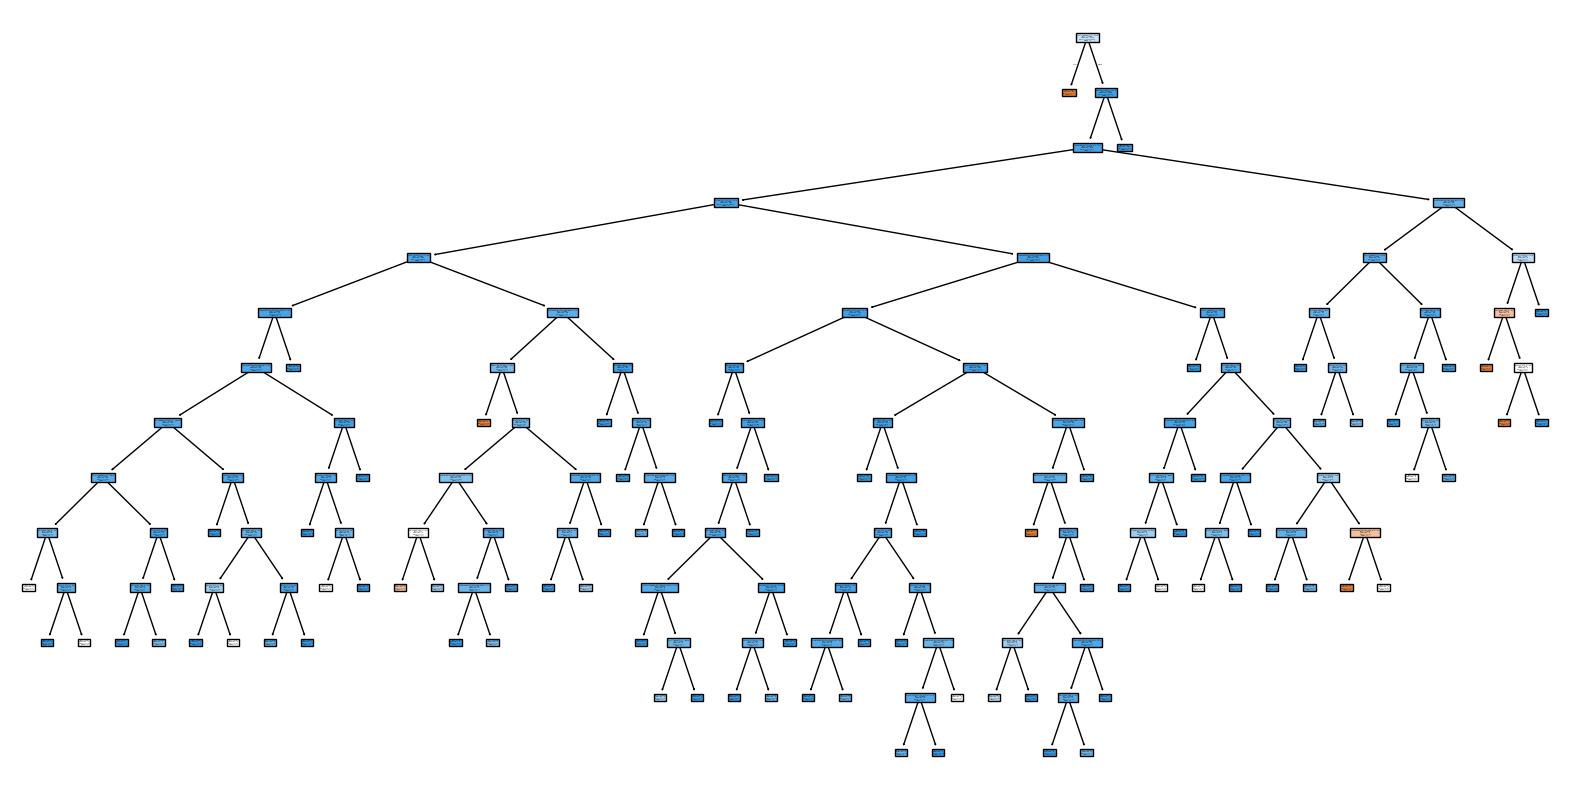

In [24]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
plt.figure(figsize=(20,10))
plot_tree(tree, filled=True, feature_names=X.columns, class_names=["0","1"])
plt.show()


In [25]:
from sklearn.metrics import accuracy_score
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)
print("Training Accuracy:", train_acc)
print("Testing Accuracy:", test_acc)

Training Accuracy: 0.9871550903901046
Testing Accuracy: 0.9581749049429658


In [26]:
import pandas as pd
feature_importsnce = pd.Series(tree.feature_importances_, index=X.columns)
print(feature_importance.sort_values(ascending=False).head(10))

Trash(in bundles)              0.973459
Nursery_wet                    0.004975
Soil Types_clay                0.003414
Variety_ponmani                0.003117
Seedrate(in Kg)                0.002976
Relative Humidity_D91_D120     0.001508
Wind Direction_D91_D120_WSW    0.001450
Max temp_D1_D30                0.001291
Wind Direction_D61_D90_SE      0.001281
Wind Direction_D31_D60_ENE     0.000829
dtype: float64


In [27]:
print("Number od nodes:", tree.tree_.node_count)
print("Frist split variable:", X.columns[tree.tree_.feature[0]])

Number od nodes: 159
Frist split variable: Trash(in bundles)


In [28]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'max_depth' : [3,5,10,None],
    'min_samples_split' : [2,5,10]
}
grid  = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5)
grid.fit(X_train, y_train)
print("Best parameters:", grid.best_params_)

Best parameters: {'max_depth': 3, 'min_samples_split': 2}


In [29]:
best_tree = grid.best_estimator_
y_train_pred_best = best_tree.predict(X_train)
y_test_pred_best = best_tree.predict(X_test)
from sklearn.metrics import accuracy_score
print("Optomized Training Accuracy:", accuracy_score(y_train, y_train_pred_best))
print("Optomized Testing Accuracy:", accuracy_score(y_test, y_test_pred_best))

Optomized Training Accuracy: 0.9843006660323501
Optomized Testing Accuracy: 0.9771863117870723


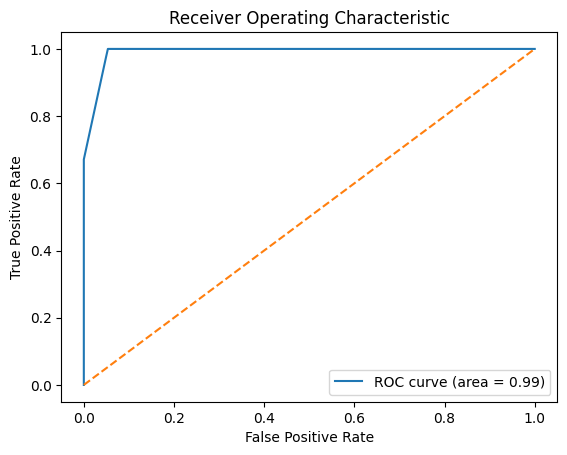

In [30]:
from sklearn.metrics import roc_curve, auc
y_probs = best_tree.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)
import matplotlib.pyplot as plt
plt.figure()
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic")
plt.legend()
plt.show()


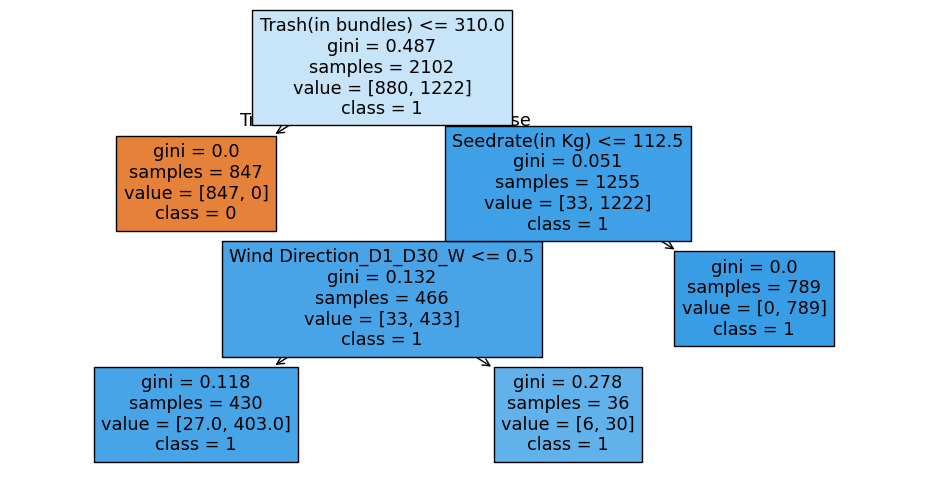

In [31]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plot_tree(best_tree, filled=True, feature_names=X.columns, class_names=["0", "1"])
plt.show()

Task 3 regression model

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metricsimport accuracy_score, roc_curve, auc
import matplotlib.pyplot as plt
import pandas as pd

SyntaxError: invalid syntax (4073069941.py, line 3)

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, roc_curve, auc
import matplotlib.pyplot as plt
import pandas as pd

creating logistic regression model

In [34]:
Log_reg = LogisticRegression(max_iter=1000, random_state=42)


Setting parameters for GridSearchCV

In [35]:
param_grid_lr = {
    "C": [0.01, 0.1, 1, 10],
   "solver": ["liblinear", "saga"]
}


Applying GridSearchCV

In [36]:
grid_lr = GridSearchCV(
    estimator=Log_reg,
    param_grid=param_grid_lr,
    cv=5,
    scoring="accuracy"
)

Train the model

In [ ]:
grid_lr.fit(X_tarin, y_train)

In [37]:
grid_lr.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which 

GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=1000, random_state=42),
             param_grid={'C': [0.01, 0.1, 1, 10],
                         'solver': ['liblinear', 'saga']},
             scoring='accuracy')

Checking best parameters

In [38]:
print("Best parameters:", grid_lr.best_params_)

Best parameters: {'C': 0.01, 'solver': 'liblinear'}


In [39]:
best_lr = grid_lr.best_estimator_


Training and testing data

In [40]:
y_train_pred_lr = best_lr.predict(X_train)
y_test_pred_lr = best_lr.predict(X_test)

In [41]:
train_acc_lr = accuracy_score(y_train, y_train_pred_lr)
test_acc_lr = accuracy_score(y_test, y_test_pred_lr)
print("Logistic Regression Training Accuracy:", train_acc_lr)
print("Logistic Regression Testing Accuracy:", test_acc_lr)

Logistic Regression Training Accuracy: 0.9843006660323501
Logistic Regression Testing Accuracy: 0.9771863117870723


Top 10 important variables

In [42]:
coefficinets = pd.Series(best_lr.coef_[0], index=X.columns)
top_10_lr = coefficients.abs().sort_values(ascending=False).head(10)
print("Top 10 important variables:")
print(top_10_lr)

NameError: name 'coefficients' is not defined

In [43]:
coefficients = pd.Series(best_lr.coef_[0], index=X.columns)
top_10_lr = coefficients.abs().sort_values(ascending=False).head(10)
print("Top 10 important variables:")
print(top_10_lr)

Top 10 important variables:
Seedrate(in Kg)                      0.298995
30_50DRain( in mm)                   0.068074
51_70DRain(in mm)                    0.060547
Relative Humidity_D91_D120           0.041408
Relative Humidity_D1_D30             0.039008
Inst Wind Speed_D61_D90(in Knots)    0.027799
Max temp_D91_D120                    0.027418
Wind Direction_D1_D30_W              0.018128
Variety_ponmani                      0.016013
Relative Humidity_D61_D90            0.014953
dtype: float64


Roc curve for Logistic Regression

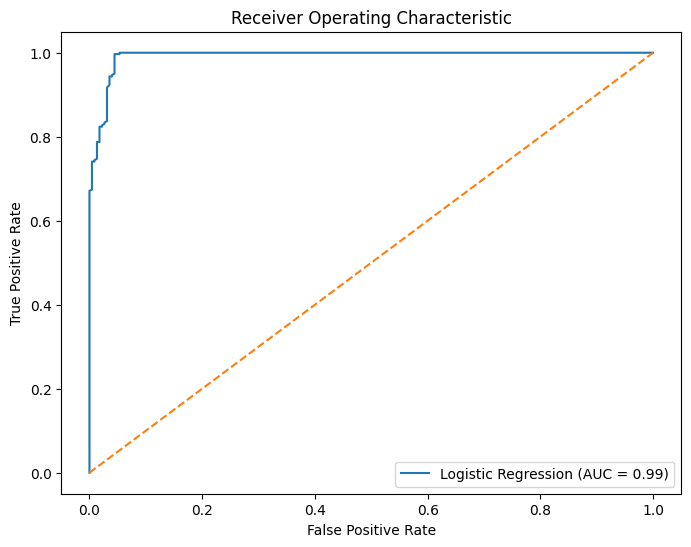

In [44]:
y_prob_lr = best_lr.predict_proba(X_test)[:,1]
fpr_lr, tpr_lr, thresholds_lr = roc_curve(y_test, y_prob_lr)
auc_lr = auc(fpr_lr, tpr_lr)
plt.figure(figsize=(8,6))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {auc_lr:.2f})")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic")
plt.legend()
plt.show()


Selecting Reduced feqtures

In [45]:
Selected_features = [
    "Trash(in bundles)",
    "Nursery_wet",
    "Soil Types_clay",
    "Variety_ponmani",
    "Seedrate(in Kg)"
]

In [46]:
X_train_reduced = X_train[Selected_features]
X_test_reduced = X_test[Selected_features]

Creating Reduced logistic regression model

In [47]:
log_reg_reduced = LogisticRegression(max_iter=1000, random_state=42)

In [48]:
grid_lr_reduced = GridSearchCV(
    estimator=log_reg_reduced,
    param_grid=param_grid_lr,
    cv=5,
    scoring="accuracy"
)

Training Reduced Model

In [49]:

grid_lr_reduced.fit(X_train_reduced, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which 

GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=1000, random_state=42),
             param_grid={'C': [0.01, 0.1, 1, 10],
                         'solver': ['liblinear', 'saga']},
             scoring='accuracy')

In [50]:
print("Best parameters for reduced model:", grid_lr_reduced.best_params_)

Best parameters for reduced model: {'C': 1, 'solver': 'liblinear'}


In [51]:
y_train_pred_lr_reduced = grid_lr_reduced.predict(X_train_reduced)
y_test_pred_lr_reduced = grid_lr_reduced.predict(X_test_reduced)

ROC curve for reduced logistic regression

In [52]:
best_lr_reduced = grid_lr_reduced.best_estimator_

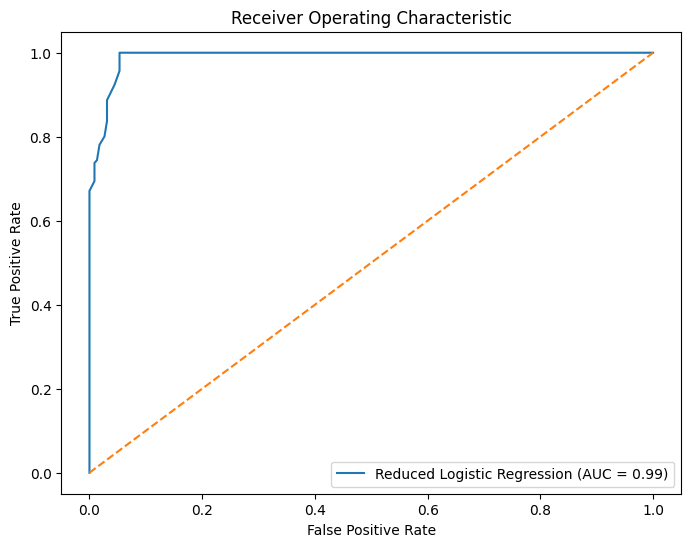

Reduced model AUC Score: 0.9905131044665928


In [53]:
y_prob_lr_reduced = best_lr_reduced.predict_proba(X_test_reduced)[:,1]
fpr_lr_reduced, tpr_lr_reduced, thresholds_lr_reduced = roc_curve(y_test, y_prob_lr_reduced)
auc_lr_reduced = auc(fpr_lr_reduced, tpr_lr_reduced)
plt.figure(figsize=(8,6))
plt.plot(fpr_lr_reduced, tpr_lr_reduced, label=f"Reduced Logistic Regression (AUC = {auc_lr_reduced:.2f})")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic")
plt.legend()
plt.show()
print("Reduced model AUC Score:", auc_lr_reduced)

Featuring important coefficients

In [54]:
coefficients_reduced = pd.Series(best_lr_reduced.coef_[0], index=Selected_features)
top_10_lr_reduced = coefficients_reduced.abs().sort_values(ascending=False).head(10)
print(top_10)

Trash(in bundles)              0.973459
Nursery_wet                    0.004975
Soil Types_clay                0.003414
Variety_ponmani                0.003117
Seedrate(in Kg)                0.002976
Relative Humidity_D91_D120     0.001508
Wind Direction_D91_D120_WSW    0.001450
Max temp_D1_D30                0.001291
Wind Direction_D61_D90_SE      0.001281
Wind Direction_D31_D60_ENE     0.000829
dtype: float64


Task 4 --- Neural Network (MLP)

Import Libraries

In [55]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, roc_curve, auc
import matplotlib.pyplot as plt

In [56]:
nn_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(max_iter=1000, random_state=42))
])

In [57]:
param_grid_nn = {
    "mlp__hidden_layer_sizes": [(10,), (20,), (30,), (20,10)],
    "mlp__activation": ["relu", "tanh"],
    "mlp__alpha": [0.0001, 0.001, 0.01]
}

Applying GridSearchCV

In [58]:
grid_nn = GridSearchCV(
    estimator=nn_pipeline,
    param_grid=param_grid_nn,
    cv=5,
    scoring="accuracy"
)

Training the model

In [59]:
grid_nn.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('mlp',
                                        MLPClassifier(max_iter=1000,
                                                      random_state=42))]),
             param_grid={'mlp__activation': ['relu', 'tanh'],
                         'mlp__alpha': [0.0001, 0.001, 0.01],
                         'mlp__hidden_layer_sizes': [(10,), (20,), (30,),
                                                     (20, 10)]},
             scoring='accuracy')

best parameters

In [60]:
print("Best parameters:", grid_nn.best_params_)

Best parameters: {'mlp__activation': 'relu', 'mlp__alpha': 0.0001, 'mlp__hidden_layer_sizes': (20,)}


Save best model

In [61]:
best_nn = grid_nn.best_estimator_

Predictions

In [62]:
y_train_pred_nn = best_nn.predict(X_train)
y_test_pred_nn = best_nn.predict(X_test)

In [63]:
train_acc_nn = accuracy_score(y_train, y_train_pred_nn)
test_acc_nn = accuracy_score(y_test, y_test_pred_nn)
print("Neural Network Training Accuracy:", train_acc_nn)
print("Neural Network Testing Accuracy:", test_acc_nn)

Neural Network Training Accuracy: 0.9857278782112274
Neural Network Testing Accuracy: 0.9752851711026616


ROC Curve

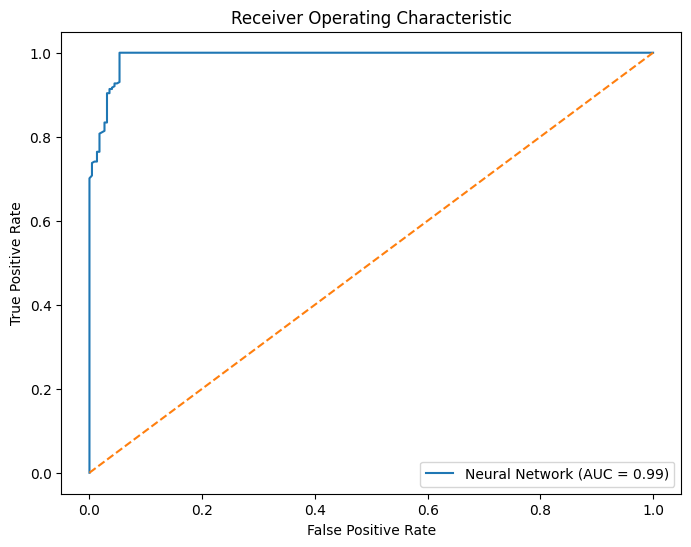

Neural Network AUC Score: 0.9910889627168696


In [64]:
y_prob_nn = best_nn.predict_proba(X_test)[:,1]
fpr_nn, tpr_nn, thresholds_nn = roc_curve(y_test, y_prob_nn)
auc_nn = auc(fpr_nn, tpr_nn)
plt.figure(figsize=(8,6))
plt.plot(fpr_nn, tpr_nn, label=f"Neural Network (AUC = {auc_nn:.2f})")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic")
plt.legend()
plt.show()
print("Neural Network AUC Score:", auc_nn)


In [66]:
nn_pipeline_reduced = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(max_iter=1000, random_state=42))
])

In [67]:
param_grid_nn = {
    "mlp__hidden_layer_sizes": [(10,), (20,), (30,), (20,10)],
    "mlp__activation": ["relu", "tanh"],
    "mlp__alpha": [0.0001, 0.001, 0.01]

}

In [68]:
grid_nn_reduced = GridSearchCV(
    estimator=nn_pipeline_reduced,
    param_grid=param_grid_nn,
    cv=5,
    scoring="accuracy"
)

In [69]:
grid_nn_reduced.fit(X_train_reduced, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('mlp',
                                        MLPClassifier(max_iter=1000,
                                                      random_state=42))]),
             param_grid={'mlp__activation': ['relu', 'tanh'],
                         'mlp__alpha': [0.0001, 0.001, 0.01],
                         'mlp__hidden_layer_sizes': [(10,), (20,), (30,),
                                                     (20, 10)]},
             scoring='accuracy')

In [70]:
best_nn_reduced = grid_nn_reduced.best_estimator_
y_train_pred_nn_reduced = best_nn_reduced.predict(X_train_reduced_nn)
y_test_pred_nn_reduced = best_nn_reduced.predict(X_test_reduced_nn)
print("Train Accuracy:", accuracy_score(y_train, y_train_pred_nn_reduced))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred_nn_reduced))

NameError: name 'X_train_reduced_nn' is not defined

In [71]:
X_train_reduced_nn = X_train_reduced[Selected_features]
X_test_reduced_nn = X_test_reduced[Selected_features]

In [72]:
best_nn_reduced = grid_nn_reduced.best_estimator_
y_train_pred_nn_reduced = best_nn_reduced.predict(X_train_reduced_nn)
y_test_pred_nn_reduced = best_nn_reduced.predict(X_test_reduced_nn)
print("Train Accuracy:", accuracy_score(y_train, y_train_pred_nn_reduced))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred_nn_reduced))

Train Accuracy: 0.9843006660323501
Test Accuracy: 0.9771863117870723


Reduced Neural Network ROC curve

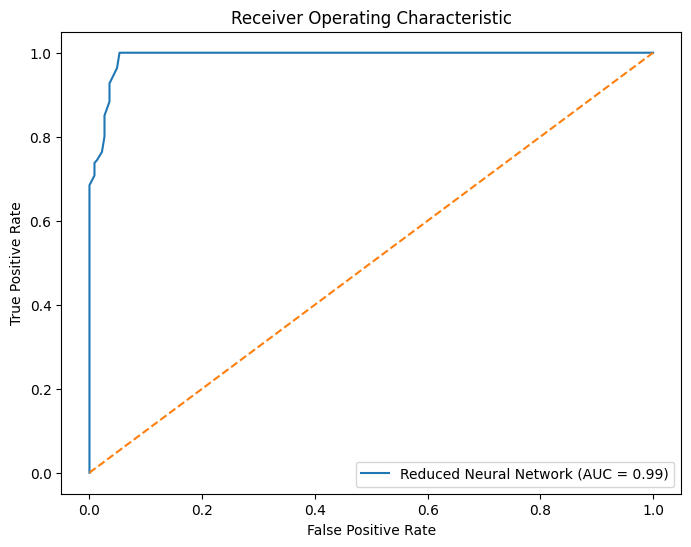

Reduced Neural Network AUC Score: 0.991000369139904


In [73]:
y_prob_nn_red = best_nn_reduced.predict_proba(X_test_reduced_nn)[:,1]
fpr_nn_red, tpr_nn_red, thresholds_nn_red = roc_curve(y_test, y_prob_nn_red)
auc_nn_red = auc(fpr_nn_red, tpr_nn_red)
plt.figure(figsize=(8,6))
plt.plot(fpr_nn_red, tpr_nn_red, label=f"Reduced Neural Network (AUC = {auc_nn_red:.2f})")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic")
plt.legend()
plt.show()
print("Reduced Neural Network AUC Score:", auc_nn_red)